In [1]:
from pathlib import Path
from IPython.display import display_markdown

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, kruskal
from scikit_posthocs import posthoc_dunn

In [2]:
results_paths = [
    Path('../../results/quantum_entropy'),
    Path('../../results/kaoetal'),
    Path('../../results/local_global_surprise')
]
corpora = [
    'humicroedit',
    'expunations',
    'HAHA@IberLEF2021'
]
corpora_paths = {
    'humicroedit': Path('../../data/humor_recognition/humicroedit.json'),
    'expunations': Path('../../data/humor_recognition/expunations.json'),
    'HAHA@IberLEF2021': Path('../../data/humor_recognition/HAHA@IberLEF2021.json')
}
metrics = [
    'QE-U + GloVe',
    'QE-I + GloVe',
    'QE-U + HF',
    'QE-I + HF',
    'local global surprise',
    'ambiguity',
    'distinctiveness'
]

In [3]:
dfs = []
for results_path in results_paths:
    for corpus in corpora:
        readpath = results_path / (corpus + '.jsonl')
        if readpath.exists():
            df = (pl.read_ndjson(readpath)
                    .with_columns(pl.lit(corpus).alias('corpus'))
                    .drop(['label', 'location', 'interpretation', 'char_count'], strict=False))
            dfs.append(df)

combined_df = pl.concat(dfs, how='diagonal_relaxed')
df = (combined_df.group_by(['index', 'text', 'corpus'])
                 .agg([pl.col(m).drop_nulls().first() for m in metrics if m in combined_df.columns]))

datasets_enum = pl.Enum(corpora)
df = (df.with_columns(pl.lit('Humor').alias('label'))
     .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,label
str,str,str,f64,f64,f64,f64,str
"""humicroedit.10664.N""","""Trump , Putin to hold bilatera…","""humicroedit""",4.990154,-4.900257,0.657176,-0.460951,"""Humor"""
"""humicroedit.10309.H""","""A Democrat on Trump 's voter f…","""humicroedit""",5.064549,-4.920677,0.601402,-0.36976,"""Humor"""
"""humicroedit.10816.H""","""“ POTUS has created an incubat…","""humicroedit""",5.156816,-5.070592,0.526403,-0.319885,"""Humor"""
"""humicroedit.4776.N""","""Trump Considering New Russia S…","""humicroedit""",5.251597,-5.182146,0.586784,-0.394031,"""Humor"""
"""humicroedit.6157.H""","""Net neutrality comments mostly…","""humicroedit""",5.286103,-5.236745,0.56082,-0.384819,"""Humor"""
…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet9524""","""Últimamente me he llevado tan …","""HAHA@IberLEF2021""",5.272537,-5.189327,0.567321,-0.371667,"""Humor"""
"""HAHA@IberLEF2021.tweet22716""","""Me encantan los domingos, lást…","""HAHA@IberLEF2021""",5.316506,-5.264964,0.609553,-0.306359,"""Humor"""
"""HAHA@IberLEF2021.tweet20649""","""De los Reggaetoneros que escuc…","""HAHA@IberLEF2021""",5.331185,-5.286555,0.606518,-0.350019,"""Humor"""


In [4]:
corpora_dfs = []
for corpus in corpora:
    corpus_df = pd.read_json(corpora_paths[corpus], orient='index')
    corpus_df = corpus_df.rename_axis('index').reset_index()
    corpus_df = corpus_df[['index', 'funniness']]
    corpora_dfs.append(pl.from_dataframe(corpus_df))

funniness_df = pl.concat(corpora_dfs)
df = df.join(funniness_df, on='index', how='left')
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,label,funniness
str,str,str,f64,f64,f64,f64,str,f64
"""humicroedit.10664.N""","""Trump , Putin to hold bilatera…","""humicroedit""",4.990154,-4.900257,0.657176,-0.460951,"""Humor""",null
"""humicroedit.10309.H""","""A Democrat on Trump 's voter f…","""humicroedit""",5.064549,-4.920677,0.601402,-0.36976,"""Humor""",0.4
"""humicroedit.10816.H""","""“ POTUS has created an incubat…","""humicroedit""",5.156816,-5.070592,0.526403,-0.319885,"""Humor""",0.8
"""humicroedit.4776.N""","""Trump Considering New Russia S…","""humicroedit""",5.251597,-5.182146,0.586784,-0.394031,"""Humor""",null
"""humicroedit.6157.H""","""Net neutrality comments mostly…","""humicroedit""",5.286103,-5.236745,0.56082,-0.384819,"""Humor""",1.0
…,…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet9524""","""Últimamente me he llevado tan …","""HAHA@IberLEF2021""",5.272537,-5.189327,0.567321,-0.371667,"""Humor""",null
"""HAHA@IberLEF2021.tweet22716""","""Me encantan los domingos, lást…","""HAHA@IberLEF2021""",5.316506,-5.264964,0.609553,-0.306359,"""Humor""",3.0
"""HAHA@IberLEF2021.tweet20649""","""De los Reggaetoneros que escuc…","""HAHA@IberLEF2021""",5.331185,-5.286555,0.606518,-0.350019,"""Humor""",2.0


In [5]:
df = df.filter(~pl.col('funniness').is_null())
df.group_by('corpus').len()

corpus,len
str,u64
"""expunations""",445
"""humicroedit""",3211
"""HAHA@IberLEF2021""",3001


### Quantile analysis

In [6]:
melted_df = df.unpivot(on=None, variable_name='metric',
                       index=['index', 'text', 'corpus', 'label', 'funniness'])
melted_df

index,text,corpus,label,funniness,metric,value
str,str,str,str,f64,str,f64
"""humicroedit.10309.H""","""A Democrat on Trump 's voter f…","""humicroedit""","""Humor""",0.4,"""QE-U + GloVe""",5.064549
"""humicroedit.10816.H""","""“ POTUS has created an incubat…","""humicroedit""","""Humor""",0.8,"""QE-U + GloVe""",5.156816
"""humicroedit.6157.H""","""Net neutrality comments mostly…","""humicroedit""","""Humor""",1.0,"""QE-U + GloVe""",5.286103
"""humicroedit.5349.H""","""Days after Hawaii alert gaffe …","""humicroedit""","""Humor""",0.0,"""QE-U + GloVe""",5.099036
"""humicroedit.10395.H""","""Pentagon claims 2,000 % increa…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.197837
…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet5885""","""Hugo Chávez en restaurante: -T…","""HAHA@IberLEF2021""","""Humor""",1.5,"""QE-I + HF""",-0.379704
"""HAHA@IberLEF2021.tweet22716""","""Me encantan los domingos, lást…","""HAHA@IberLEF2021""","""Humor""",3.0,"""QE-I + HF""",-0.306359
"""HAHA@IberLEF2021.tweet20649""","""De los Reggaetoneros que escuc…","""HAHA@IberLEF2021""","""Humor""",2.0,"""QE-I + HF""",-0.350019


In [7]:
quantiles = (melted_df.group_by(['corpus', 'metric'])
                      .agg(pl.col('value').quantile(0.25).alias('Q1'),
                           pl.col('value').quantile(0.5).alias('Q2'),
                           pl.col('value').quantile(0.75).alias('Q3'))
                      .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
                      .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                                    (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))

with pl.Config(tbl_rows=12):
    display(quantiles.sort(pl.col('corpus').cast(datasets_enum)))

corpus,metric,Q1,Q2,Q3,IQR,F1,F2
str,str,f64,f64,f64,f64,f64,f64
"""humicroedit""","""QE-I + GloVe""",-5.183389,-5.077046,-4.94812,0.235269,-5.536293,-4.595217
"""humicroedit""","""QE-U + HF""",0.528869,0.559969,0.595487,0.066619,0.428941,0.695415
"""humicroedit""","""QE-U + GloVe""",5.05372,5.173874,5.264197,0.210478,4.738003,5.579914
"""humicroedit""","""QE-I + HF""",-0.396873,-0.366344,-0.335613,0.061259,-0.488762,-0.243724
"""expunations""","""QE-I + HF""",-0.361454,-0.326744,-0.290875,0.070579,-0.467323,-0.185006
"""expunations""","""QE-U + GloVe""",4.928157,5.000472,5.07409,0.145933,4.709258,5.292989
"""expunations""","""QE-U + HF""",0.534335,0.560551,0.591667,0.057331,0.448339,0.677663
"""expunations""","""QE-I + GloVe""",-4.944371,-4.87032,-4.788182,0.156189,-5.178654,-4.553898
"""HAHA@IberLEF2021""","""QE-I + GloVe""",-5.267751,-5.202873,-5.128382,0.139369,-5.476804,-4.919329


In [8]:
df_with_quantiles = melted_df.join(quantiles, on=['corpus', 'metric'])
is_low_outlier = (pl.col('value') < pl.col('F1'))
is_high_outlier = (pl.col('value') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(melted_df.columns)

df_no_outliers.group_by('corpus').len()

corpus,len
str,u64
"""expunations""",1695
"""humicroedit""",12311
"""HAHA@IberLEF2021""",11291


### Correlation analysis

In [9]:
corr_df = (
    df_no_outliers
    .drop_nulls(subset=['funniness', 'value'])
    .group_by(['corpus', 'metric'])
    .agg(
        pl.corr(pl.col('funniness'), pl.col('value')).alias('correlation')
    )
)

metrics_enum = pl.Enum(metrics)
with pl.Config(tbl_rows=12):
    display(corr_df.sort(pl.col('metric').cast(metrics_enum),
                         pl.col('corpus').cast(datasets_enum)))

corpus,metric,correlation
str,str,f64
"""humicroedit""","""QE-U + GloVe""",0.003702
"""expunations""","""QE-U + GloVe""",-0.022143
"""HAHA@IberLEF2021""","""QE-U + GloVe""",0.056272
"""humicroedit""","""QE-I + GloVe""",0.007743
"""expunations""","""QE-I + GloVe""",0.055523
"""HAHA@IberLEF2021""","""QE-I + GloVe""",-0.061034
"""humicroedit""","""QE-U + HF""",0.006446
"""expunations""","""QE-U + HF""",0.046153
"""HAHA@IberLEF2021""","""QE-U + HF""",0.025101


## Plots

### Funniness

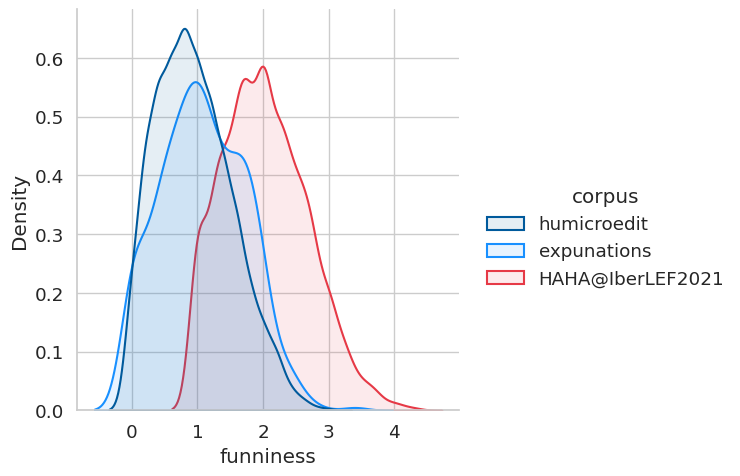

In [10]:
sns.set_theme(style="whitegrid", font_scale=1.2)

corpus_palette = {
    'humicroedit': '#005A9C',
    'expunations': '#1890FF',
    'HAHA@IberLEF2021': '#E63946',
}

sns.displot(
    df,
    x='funniness',
    hue='corpus',
    kind='kde',
    common_norm=False,
    palette=corpus_palette,
    fill=True,
    alpha=0.1,
    linewidth=1.5,
    hue_order=corpora
)

### Funniness vs. Metrics

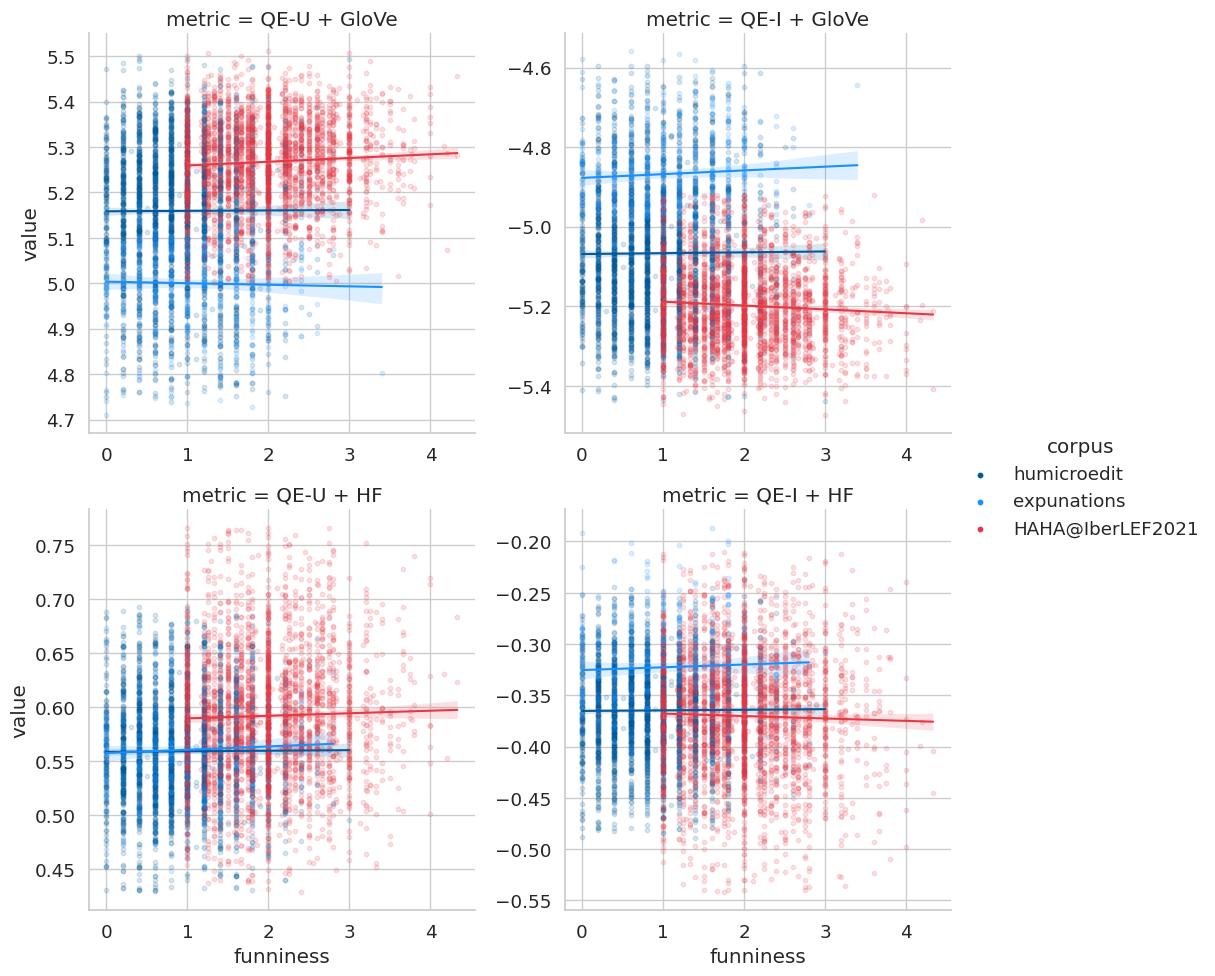

In [11]:
g = sns.lmplot(
    data=df_no_outliers, 
    x='funniness', 
    y='value', 
    hue='corpus', 
    col='metric', 
    col_wrap=2,
    palette=corpus_palette, 
    facet_kws={'sharex': False, 'sharey': False, 'legend_out': True},
    scatter_kws={'alpha': 0.15, 's': 10},
    line_kws={'linewidth': 1.5},
    hue_order=corpora
)

for handle in g.legend.legend_handles:
    handle.set_alpha(1.0)
plt.show()

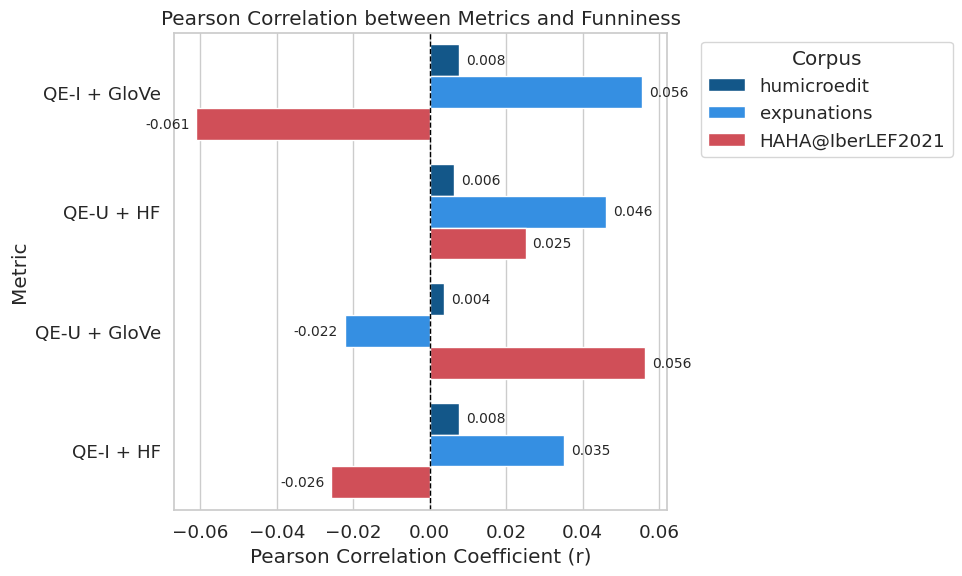

In [12]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=corr_df, 
    x='correlation', 
    y='metric', 
    hue='corpus', 
    palette=corpus_palette,
    hue_order=corpora
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt='%.3f', padding=5)

plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Pearson Correlation between Metrics and Funniness')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Metric')
plt.legend(title='Corpus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Binned analysis

In [13]:
binned_df = df_no_outliers.with_columns(
    pl.col('funniness')
    .qcut(3, labels=['low', 'mid', 'high'])
    .over(['corpus', 'metric'])
    .alias('funniness bin')
)
binned_df

index,text,corpus,label,funniness,metric,value,funniness bin
str,str,str,str,f64,str,f64,cat
"""humicroedit.10309.H""","""A Democrat on Trump 's voter f…","""humicroedit""","""Humor""",0.4,"""QE-U + GloVe""",5.064549,"""low"""
"""humicroedit.10816.H""","""“ POTUS has created an incubat…","""humicroedit""","""Humor""",0.8,"""QE-U + GloVe""",5.156816,"""mid"""
"""humicroedit.6157.H""","""Net neutrality comments mostly…","""humicroedit""","""Humor""",1.0,"""QE-U + GloVe""",5.286103,"""mid"""
"""humicroedit.5349.H""","""Days after Hawaii alert gaffe …","""humicroedit""","""Humor""",0.0,"""QE-U + GloVe""",5.099036,"""low"""
"""humicroedit.10395.H""","""Pentagon claims 2,000 % increa…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.197837,"""low"""
…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet5885""","""Hugo Chávez en restaurante: -T…","""HAHA@IberLEF2021""","""Humor""",1.5,"""QE-I + HF""",-0.379704,"""low"""
"""HAHA@IberLEF2021.tweet22716""","""Me encantan los domingos, lást…","""HAHA@IberLEF2021""","""Humor""",3.0,"""QE-I + HF""",-0.306359,"""high"""
"""HAHA@IberLEF2021.tweet20649""","""De los Reggaetoneros que escuc…","""HAHA@IberLEF2021""","""Humor""",2.0,"""QE-I + HF""",-0.350019,"""mid"""


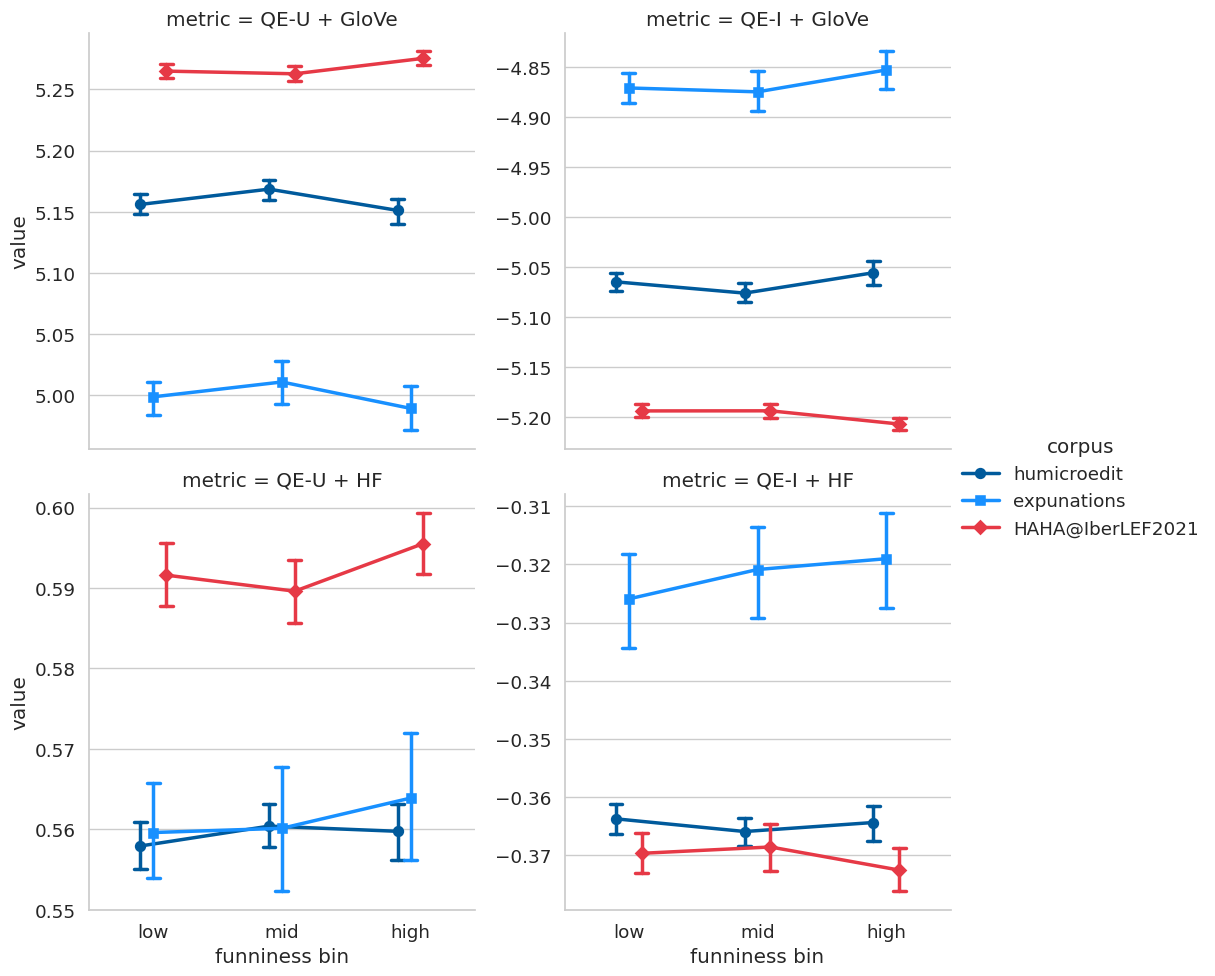

In [14]:
sns.catplot(
    data=binned_df,
    x='funniness bin',
    y='value',
    hue='corpus',
    col='metric',
    col_wrap=2,
    order=['low', 'mid', 'high'],
    sharey=False,
    palette=corpus_palette,
    kind='point',
    dodge=0.2,
    capsize=0.1,
    markers=['o', 's', 'D'],
    linewidth=2.5,
    hue_order=corpora
)

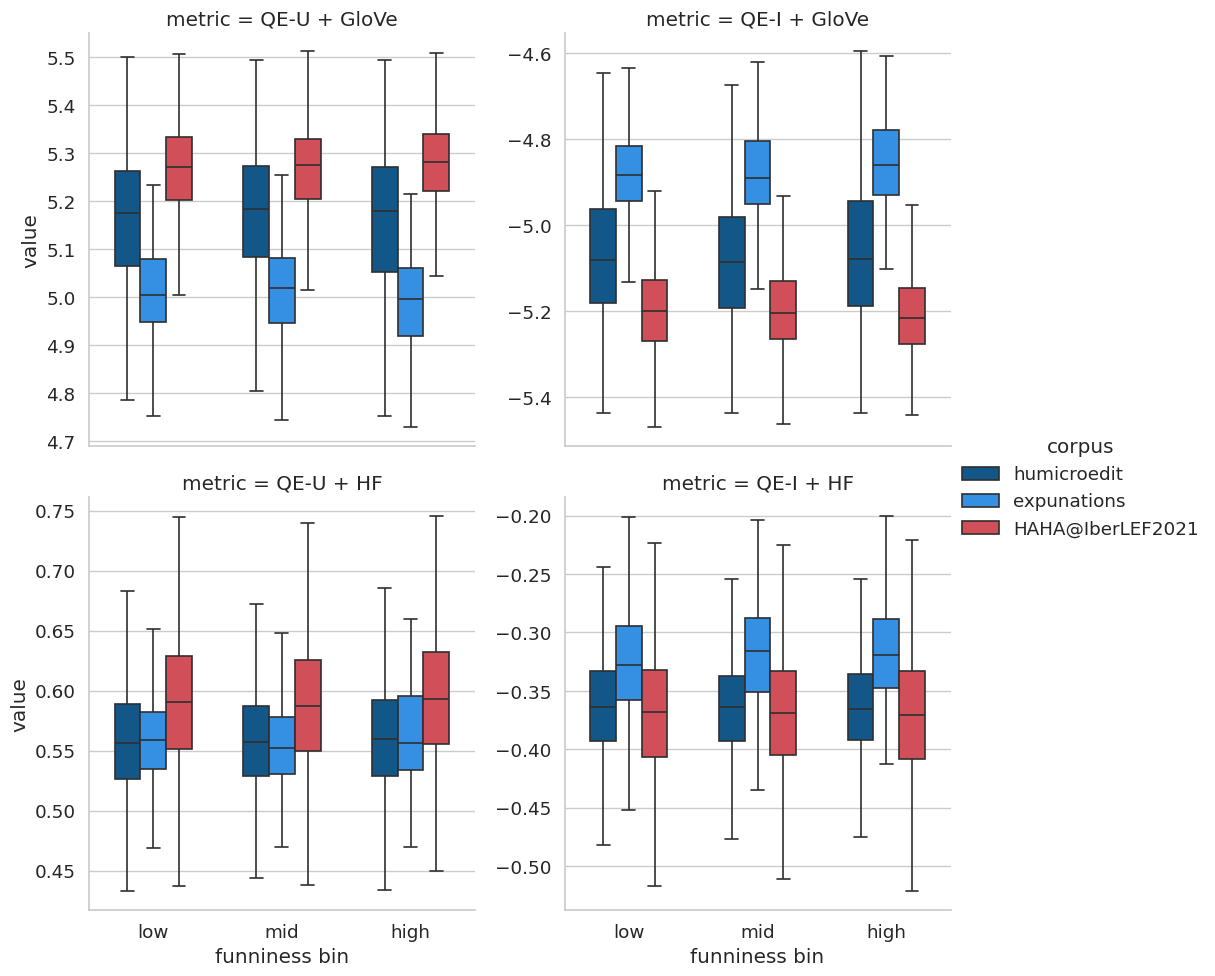

In [15]:
sns.catplot(
    data=binned_df,
    x='funniness bin',
    y='value',
    hue='corpus',
    col='metric',
    col_wrap=2,
    kind='box',
    order=['low', 'mid', 'high'],
    palette=corpus_palette,
    sharey=False,
    showfliers=False,
    width=0.6,
    linewidth=1.2
)

## Statistical tests (no outliers)

### Binned Analysis (Kruskall-Wallis H-test)

In [43]:
results = []
for metric in metrics:
    for corpus in corpora:
        binned_metric = (
            binned_df
            .filter((pl.col('metric') == metric) & (pl.col('corpus') == corpus))
            .select(['value', 'funniness bin'])
            .group_by('funniness bin')
            .all()['value']
            .to_numpy()
        )
        if binned_metric.shape == (3,):
            statistic, pvalue = kruskal(*binned_metric)

            dunn_result = posthoc_dunn(binned_metric, p_adjust='bonferroni')
            dunn_result.columns = ['low', 'mid', 'high']
            dunn_result.index = ['low', 'mid', 'high']

            results.append({
                'metric': metric,
                'corpus': corpus,
                'statistic': statistic,
                'p value': pvalue,
                'significantly different': pvalue < 0.05,
                'low vs mid dunn': dunn_result.loc['low', 'mid'],
                'low vs high dunn': dunn_result.loc['low', 'high'],
                'mid vs high dunn': dunn_result.loc['mid', 'high']
            })


results_df = (
    pl.DataFrame(results)
      .sort(
        pl.col('metric').cast(metrics_enum),
        pl.col('corpus').cast(datasets_enum)
        )
    )

with pl.Config(tbl_rows=12):
    display(results_df)

metric,corpus,statistic,p value,significantly different,low vs mid dunn,low vs high dunn,mid vs high dunn
str,str,f64,f64,i64,f64,f64,f64
"""QE-U + GloVe""","""humicroedit""",5.296945,0.070759,0,0.134787,1.0,0.160961
"""QE-U + GloVe""","""expunations""",3.508741,0.173016,0,0.699193,0.187921,1.0
"""QE-U + GloVe""","""HAHA@IberLEF2021""",8.015468,0.018175,1,1.0,0.050606,0.035431
"""QE-I + GloVe""","""humicroedit""",5.053128,0.079933,0,0.302191,1.0,0.10159
"""QE-I + GloVe""","""expunations""",4.055758,0.131614,0,0.207621,1.0,0.253772
"""QE-I + GloVe""","""HAHA@IberLEF2021""",8.484489,0.014375,1,1.0,0.030065,0.039611
"""QE-U + HF""","""humicroedit""",1.443479,0.485906,0,1.0,0.714571,1.0
"""QE-U + HF""","""expunations""",0.600851,0.740503,0,1.0,1.0,1.0
"""QE-U + HF""","""HAHA@IberLEF2021""",4.413304,0.110069,0,1.0,0.519471,0.115144
